In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import sys
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import lightning as L
import wandb
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import random_split, DataLoader
from monai.networks.nets import UNet

sys.path.append('../')
from dataset import PMRIDataset, MNMv2Dataset, ACDCDataset
from data_utils import (
    PMRIDataModule,
    MNMv2DataModule
)
from model.unet import get_unet


nnUNet_raw_data_base is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
RESULTS_FOLDER is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.


In [18]:
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU



class LightningSegmentationModel(L.LightningModule):
    #TODO: change init to receive only config and save it as hyperparameter. Add get_unet method to get the model
    def __init__(
        self,
        model: torch.nn.Module,
        lr: float = 1e-3,
        patience: int = 5,
        binary_target: bool = False,
    ):
        super().__init__()
        # this would save the model as hyperparameter, not desired!
        # self.save_hyperparameters()
        self.model = model
        self.lr = lr
        self.patience = patience
        self.loss = DiceCELoss(
            softmax=False if binary_target else True,
            sigmoid=True if binary_target else False,
            to_onehot_y=False if binary_target else True,
        )
        self.dsc = DiceMetric(include_background=False, reduction="none")
        self.IoU = MeanIoU(include_background=False, reduction="none")

    def forward(self, inputs):        
        return self.model(inputs)
    
    def training_step(self, batch, batch_idx):
        input = batch['data']
        target = batch['target']
        outputs = self(input)
        loss = self.loss(outputs, target)
        num_classes = max(outputs.shape[1], 2)
        if num_classes > 2:
            outputs = outputs.argmax(1)
        else:
            outputs = (outputs > 0.5) * 1
        outputs = torch.nn.functional.one_hot(outputs, num_classes=num_classes).moveaxis(-1, 1)
        dsc = self.dsc(outputs, target).nanmean()

        self.log_dict({
            'train_loss': loss,
            'train_dsc': dsc,
        })
        return {
            'loss': loss
        }
    
    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        input = batch['input']
        target = batch['target']
        
        outputs = self(input)
        loss = self.loss(outputs, target)
        num_classes = max(outputs.shape[1], 2)
        if num_classes > 2:
            outputs = outputs.argmax(1)
        else:
            outputs = (outputs > 0) * 1
        outputs = torch.nn.functional.one_hot(outputs, num_classes=num_classes).moveaxis(-1, 1)
        dsc = self.dsc(outputs, target).nanmean()

        self.log_dict({
            'val_loss': loss,
            'val_dsc': dsc,
        })
        return {
            'loss': loss,
        }
    
    def test_step(self, batch, batch_idx, dataloader_idx=0):
        input = batch['input']
        target = batch['target']
        outputs = self(input)
        loss = self.loss(outputs, target)
        num_classes = max(outputs.shape[1], 2)
        if num_classes > 2:
            outputs = outputs.argmax(1)
        else:
            outputs = (outputs > 0) * 1
        outputs = torch.nn.functional.one_hot(outputs, num_classes=num_classes).moveaxis(-1, 1)
        dsc = dice_metric(outputs, target).nanmean()


        self.log_dict({
            'test_loss': loss,
            'test_dsc': dsc,
        })
        return {
            'loss': loss,
            'dsc': dsc
        }
    
    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        input = batch['input']
        outputs = self(input)
        return outputs
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=self.patience),
                'monitor': 'val_loss',
                'frequency': 1,
            }
        }
    



In [20]:
pmri_datamodule = PMRIDataModule(
    data_dir="../../../../../data/PMRI/",
    vendor_assignment={'train': 'ge', 'test': 'philips'},
    batch_size=32
)

n_filters_init = 8
depth = 4

unet = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=[n_filters_init * 2 ** i for i in range(depth)],
    strides=[2] * (depth - 1),
    num_res_units=4
)

lightning_unet = LightningSegmentationModel(
    model = unet,
    binary_target=True,
    lr=1e-3,
)


# default logger used by trainer (if tensorboard is installed)

wandb.finish()
wandb_logger = WandbLogger(
    project="lightning", 
    log_model=True, 
    name="pmri_unet"
)
trainer = L.Trainer(
    limit_train_batches=50,
    max_epochs=100,
    logger=wandb_logger,
    callbacks=[
        EarlyStopping(monitor="val_loss", mode="min", patience=lightning_unet.patience * 2),
        ModelCheckpoint(
            dirpath='../../pre-trained/trained_UNets',
            filename='pmri-{epoch:02d}-{val_loss:.2f}', #TODO: Change filename with config
            save_top_k=2, 
            monitor="val_loss"
        )
    ],
    precision='16-mixed',
    gradient_clip_val=0.5,
)
trainer.fit(lightning_unet, pmri_datamodule)

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
train_dsc,▁▃▆▆▇▇▇▇▇█
train_loss,█▇▅▅▄▂▄▃▃▁
trainer/global_step,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
val_dsc,▁▂▄▆▇▇▇███
val_loss,█▆▄▃▂▂▂▁▁▁
epoch,9
train_dsc,0.77912
train_loss,1.40537
trainer/global_step,499
val_dsc,0.56177


Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/usr/local/lib/python3.10/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /out/trained_UNets exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | UNet       | 198 K  | train
1 | loss  | DiceCELoss | 0      | train
---------------------------------------------
198 K     Trainable params
0         Non-trainable params
198 K     Total params
0.795     Total estimated model params size (MB)
169       Modules in train mode
0         Modules in eval mode


Epoch 0:   0%|          | 0/50 [41:10<?, ?it/s] 2.24it/s, v_num=fe7r]      


/usr/local/lib/python3.10/dist-packages/wandb/sdk/wandb_run.py:2165: UserWarning: Run (a7xn5waa) is finished. The call to `_console_raw_callback` will be ignored. Please make sure that you are using an active run.
  lambda data: self._console_raw_callback("stdout", data),


Epoch 65: 100%|██████████| 50/50 [00:23<00:00,  2.11it/s, v_num=fe7r]


In [22]:
pmri_datamodule.setup('test')
dl = pmri_datamodule.test_dataloader()
trainer.test(lightning_unet, dataloaders=dl)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Testing DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 32.47it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_dsc          │    0.6693131923675537     │
│         test_loss         │    0.47417721152305603    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.47417721152305603, 'test_dsc': 0.6693131923675537}]

In [31]:
# pmri_datamodule.setup('test')
dl = pmri_datamodule.test_dataloader()
for batch in dl:
    break
input = batch['input']
output = lightning_unet(input)
target = batch['target']



wandb: ERROR Error while calling W&B API: context deadline exceeded (<Response [500]>)
wandb: ERROR Error while calling W&B API: context deadline exceeded (<Response [500]>)
wandb: Network error (ReadTimeout), entering retry loop.


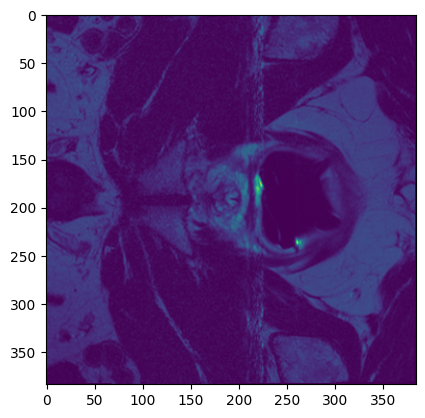

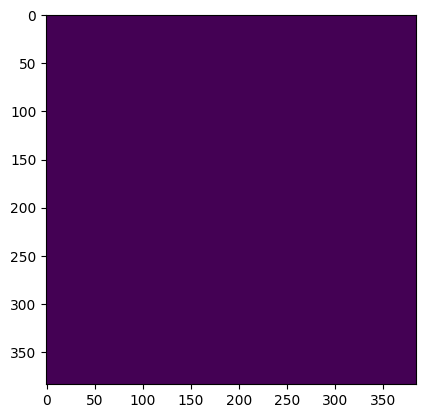

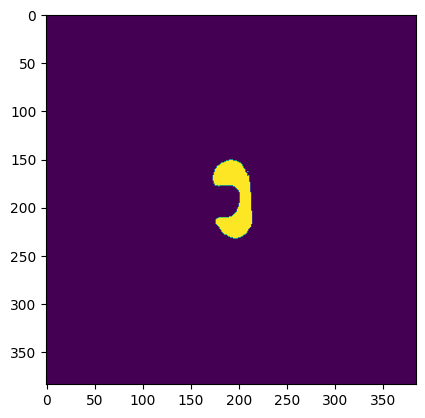

In [17]:
import matplotlib.pyplot as plt

idx = 1

plt.imshow(input[idx, 0].cpu().numpy())
plt.show()
plt.imshow(output[idx].cpu().argmax(0).detach().numpy()>0)
plt.show()
plt.imshow(target[idx, 0].cpu().numpy())
plt.show()

In [32]:
output[idx]

[autoreload of model.unet failed: Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/lib/python3.10/dist-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/usr/local/lib/python3.10/dist-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/usr/local/lib/python3.10/dist-packages/IPython/extensions/autoreload.py", line 365, in update_class
    update_instances(old, new)
  File "/usr/local/lib/python3.10/dist-packages/IPython/extensions/autoreload.py", line 319, in update_instances
    refs = gc.get_referrers(old)
KeyboardInterrupt
]


tensor([[[  4.6696,   6.2542,   5.8210,  ...,   6.4156,   6.3023,   4.4789],
         [  5.1506,   9.3750,   6.5313,  ...,   8.1436,   7.6911,   7.3589],
         [  6.4064,   7.1112,   7.6853,  ...,   7.1805,   8.7014,   5.9925],
         ...,
         [  6.0997,   9.6589,   8.5836,  ...,   7.4013,   6.2579,   5.6510],
         [  6.2520,   8.5302,   9.7039,  ...,   9.0410,   9.1698,   5.9605],
         [  4.2955,   6.5211,   6.3798,  ...,   7.3234,   6.6358,   5.2064]],

        [[ -4.7810,  -7.0388,  -4.1197,  ...,  -5.4738,  -6.7197,  -5.6203],
         [ -5.6563,  -8.0957,  -6.1349,  ...,  -8.3592,  -8.7163,  -7.2846],
         [ -5.4155,  -6.8879,  -5.6407,  ...,  -8.2006,  -9.0086,  -7.0251],
         ...,
         [ -6.9077,  -9.8390,  -8.4918,  ...,  -7.6132,  -7.2967,  -5.7552],
         [ -6.9639,  -8.8147,  -9.0283,  ...,  -9.8665, -10.5110,  -7.2678],
         [ -5.5441,  -6.7737,  -7.1569,  ...,  -7.8819,  -7.8004,  -5.2854]],

        [[ -2.1032,  -3.9628,  -2.1883,  ...

In [34]:
mnmv2_datamodule = MNMv2DataModule(
    data_dir="../../../../../data/MNM/",
    vendor_assignment={'train': 'siemens', 'test': 'ge'},
    batch_size=32,
    binary_target = False,
    non_empty_target = False
)

n_filters_init = 8
depth = 4
num_res_units = 4

unet = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=4,
    channels=[n_filters_init * 2 ** i for i in range(depth)],
    strides=[2] * (depth - 1),
    num_res_units=num_res_units
)

lightning_unet = LightningSegmentationModel(
    model=unet,
    binary_target=False,
    lr=1e-3,
)


wandb.finish()
wandb_logger = WandbLogger(project="lightning", log_model=True, name="mnmv2_unet")
trainer = L.Trainer(
    limit_train_batches=50,
    max_epochs=100,
    logger=wandb_logger,
    callbacks=[
        EarlyStopping(monitor="val_loss", mode="min", patience=lightning_unet.patience * 2),
        ModelCheckpoint(
            dirpath='../../pre-trained/trained_UNets',
            filename='mnmv2-{epoch:02d}-{val_loss:.2f}', #TODO: Change filename with config
            save_top_k=2, 
            monitor="val_loss"
        )
    ],
    precision='16-mixed',
    gradient_clip_val=0.5,
)
trainer.fit(lightning_unet, mnmv2_datamodule)

TypeError: MNMv2DataModule.__init__() got an unexpected keyword argument 'batch_target'

In [26]:
mnmv2_datamodule.setup('test')
dl = mnmv2_datamodule.test_dataloader()
trainer.test(lightning_unet, dataloaders=dl)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Testing DataLoader 0: |          | 0/? [01:09<?, ?it/s]
Testing: |          | 40/? [00:01<00:00, 29.58it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_dsc          │    0.7296077609062195     │
│         test_loss         │    0.5387300848960876     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.5387300848960876, 'test_dsc': 0.7296077609062195}]

In [28]:
# mnmv2_datamodule.setup('test')
dl = mnmv2_datamodule.test_dataloader()
for batch in dl:
    break
input = batch['input']
output = lightning_unet(input)
target = batch['target']

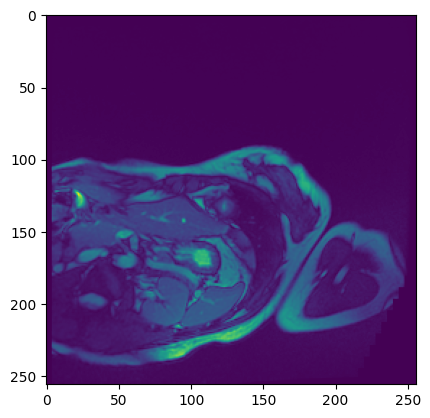

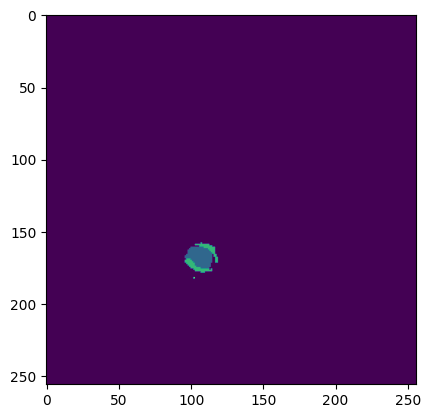

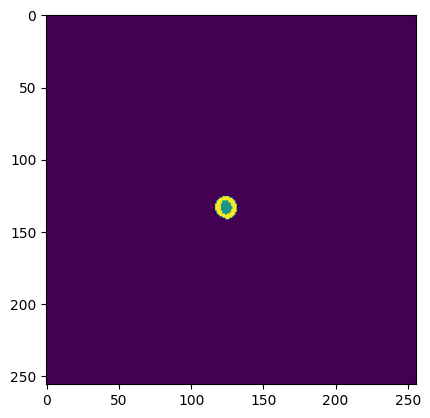

In [30]:


import matplotlib.pyplot as plt

idx = 10

plt.imshow(input[idx, 0].cpu().numpy())
plt.show()
plt.imshow(output[idx].cpu().argmax(0).detach().numpy())
plt.show()
plt.imshow(target[idx, 0].cpu().numpy())
plt.show()

In [22]:
outputs = (torch.rand(10) > 0.5) * 1

outputs = torch.nn.functional.one_hot(outputs, num_classes=2)

In [23]:
outputs

tensor([[0, 1],
        [0, 1],
        [0, 1],
        [1, 0],
        [1, 0],
        [1, 0],
        [0, 1],
        [0, 1],
        [1, 0],
        [0, 1]])

In [24]:
pmri_datamodule.setup('fit')

In [35]:
dl = pmri_datamodule.val_dataloader()

In [36]:
batch = next(dl)

In [37]:
input = batch['data']
output = lightning_unet(input)
target = batch['target']

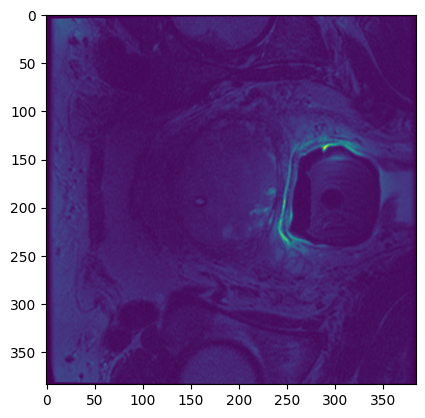

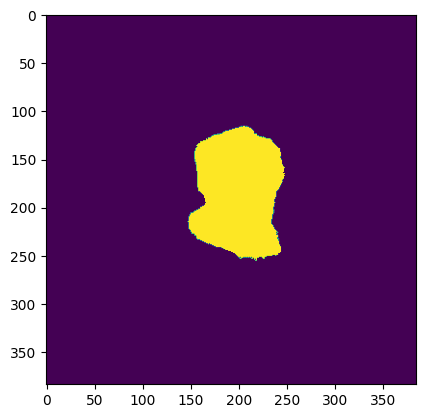

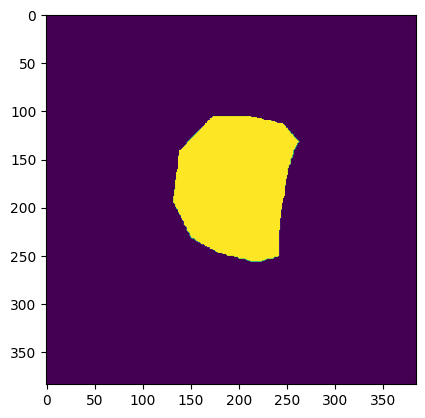

In [39]:
import matplotlib.pyplot as plt

plt.imshow(input[0, 0].cpu().numpy())
plt.show()
plt.imshow(output[0, 0].cpu().detach().numpy() > 0.5)
plt.show()
plt.imshow(target[0, 0].cpu().numpy())
plt.show()